# Codificação de Sinais Multimedia

## Trabalho Laboratorial 4

- 52146 - Margarida Andrade
- 52345 - Jorge Gonçalves
- 52708 - Helena Nina

In [1]:
import json
from pathlib import Path
import struct

import os
from time import time
import cv2
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import numpy as np

## Exercício 1
### Alínea a

Imagem usada: bola_1.tiff | shape=(240, 352)
Erro maximo apos DCT+IDCT (sem quantizacao): 1


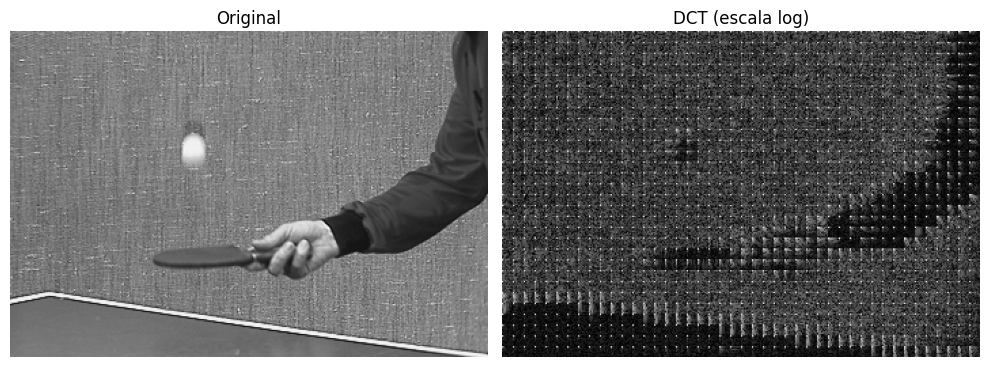

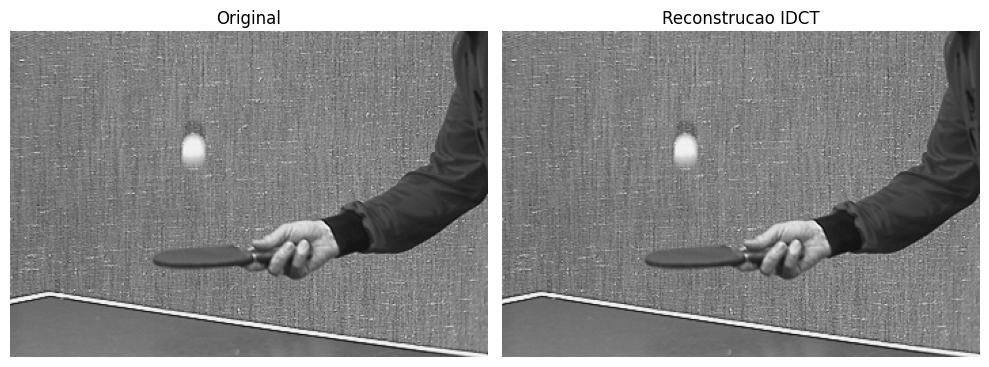

In [2]:
# ------------------------------
# Utilitários gerais do codificador JPEG sequencial (tons de cinzento)
# ------------------------------


def locate_tp4_dir():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for base in candidates:
        p = base / "Tabelas_jpeg.json"
        if p.exists():
            return base

    for p in Path.cwd().rglob("Tabelas_jpeg.json"):
        return p.parent

    raise FileNotFoundError("Nao foi possivel localizar a pasta tp4 com Tabelas_jpeg.json")


TP4_DIR = locate_tp4_dir()
IMG_PATH = TP4_DIR / "bola_seq" / "bola_1.tiff"
TABLES_PATH = TP4_DIR / "Tabelas_jpeg.json"


def load_tables_from_json(json_path: Path):
    """Carrega Q, K3, K5 e quality_factor a partir do ficheiro fornecido em tp4."""
    data = json.loads(json_path.read_text(encoding="utf-8"))

    code_src = None
    for cell in data.get("cells", []):
        if cell.get("cell_type") == "code":
            src = "".join(cell.get("source", []))
            if "Q = np.zeros((8, 8))" in src and "K3 = dict()" in src and "K5 = dict()" in src:
                code_src = src
                break

    if code_src is None:
        raise RuntimeError("Nao foi possivel encontrar as tabelas no ficheiro Tabelas_jpeg.json")

    start = code_src.find("Q = np.zeros((8, 8))")
    end = code_src.find("return factor")
    if start < 0 or end < 0:
        raise RuntimeError("Estrutura inesperada em Tabelas_jpeg.json")

    snippet = code_src[start : end + len("return factor")]
    namespace = {"np": np}
    exec(snippet, namespace)

    Q = namespace["Q"].astype(np.float32)
    K3 = namespace["K3"]
    K5 = namespace["K5"]
    quality_factor_fn = namespace["quality_factor"]
    ind_zz = namespace["ind_zz"].astype(np.int32)
    return Q, K3, K5, ind_zz, quality_factor_fn


Q, K3, K5, IND_ZZ, quality_factor = load_tables_from_json(TABLES_PATH)


def read_gray_image(path: Path):
    # imdecode + fromfile evita problemas do cv2.imread com caminhos Unicode no Windows
    data = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Imagem nao encontrada: {path}")
    return img


def pad_to_block_size(img, block=8):
    h, w = img.shape
    hp = ((h + block - 1) // block) * block
    wp = ((w + block - 1) // block) * block
    out = np.zeros((hp, wp), dtype=np.float32)
    out[:h, :w] = img.astype(np.float32)
    return out, h, w


def crop_original(img, h, w):
    return img[:h, :w]


def block_iter(img, block=8):
    h, w = img.shape
    for i in range(0, h, block):
        for j in range(0, w, block):
            yield i, j, img[i : i + block, j : j + block]


def dct2_blocks(img):
    padded, h, w = pad_to_block_size(img)
    shifted = padded - 128.0
    out = np.zeros_like(shifted, dtype=np.float32)
    for i, j, block in block_iter(shifted):
        out[i : i + 8, j : j + 8] = cv2.dct(block.astype(np.float32))
    return out, h, w


def idct2_blocks(coeff, h, w):
    out = np.zeros_like(coeff, dtype=np.float32)
    for i, j, block in block_iter(coeff):
        out[i : i + 8, j : j + 8] = cv2.idct(block.astype(np.float32))
    out = np.clip(out + 128.0, 0, 255)
    return crop_original(out, h, w).astype(np.uint8)


def show_images_side_by_side(img1, img2, title1, title2, cmap="gray"):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap=cmap)
    plt.title(title1)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(img2, cmap=cmap)
    plt.title(title2)
    plt.axis("off")
    plt.tight_layout()


def coeff_to_display(coeff):
    # visualização log para evidenciar baixas/altas frequências
    return np.log1p(np.abs(coeff))


def snr_db(original, reconstructed):
    x = original.astype(np.float64)
    y = reconstructed.astype(np.float64)
    signal = np.sum(x ** 2)
    noise = np.sum((x - y) ** 2)
    if noise == 0:
        return np.inf
    return 10 * np.log10(signal / noise)


img0 = read_gray_image(IMG_PATH)
coeff0, h0, w0 = dct2_blocks(img0)
img0_rec = idct2_blocks(coeff0, h0, w0)

print(f"Imagem usada: {IMG_PATH.name} | shape={img0.shape}")
print(f"Erro maximo apos DCT+IDCT (sem quantizacao): {np.max(np.abs(img0.astype(int) - img0_rec.astype(int)))}")

show_images_side_by_side(img0, coeff_to_display(coeff0), "Original", "DCT (escala log)")
show_images_side_by_side(img0, img0_rec, "Original", "Reconstrucao IDCT")

### Alínea b

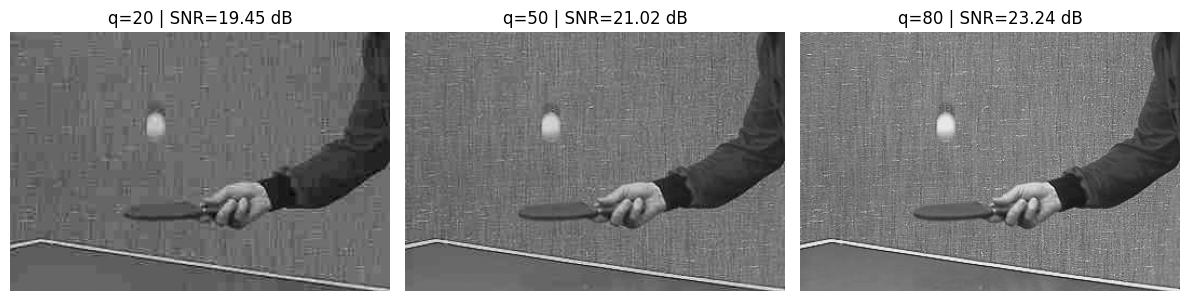

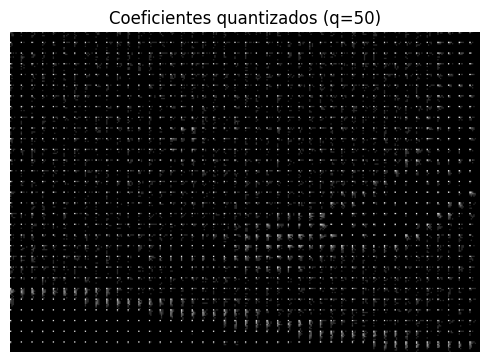

In [3]:
def quantize_blocks(coeff, q):
    factor = quality_factor(q)
    qmat = Q * factor
    out = np.zeros_like(coeff, dtype=np.int16)
    for i, j, block in block_iter(coeff):
        out[i : i + 8, j : j + 8] = np.round(block / qmat).astype(np.int16)
    return out, qmat


def dequantize_blocks(qcoeff, qmat):
    out = np.zeros_like(qcoeff, dtype=np.float32)
    for i, j, block in block_iter(qcoeff):
        out[i : i + 8, j : j + 8] = block.astype(np.float32) * qmat
    return out


img = read_gray_image(IMG_PATH)
coeff, h, w = dct2_blocks(img)

qualities = [20, 50, 80]
plt.figure(figsize=(12, 4))
for idx, q in enumerate(qualities, start=1):
    qcoeff, qmat = quantize_blocks(coeff, q)
    coeff_rec = dequantize_blocks(qcoeff, qmat)
    rec = idct2_blocks(coeff_rec, h, w)
    snr = snr_db(img, rec)

    plt.subplot(1, len(qualities), idx)
    plt.imshow(rec, cmap="gray")
    plt.title(f"q={q} | SNR={snr:.2f} dB")
    plt.axis("off")

plt.tight_layout()

q_demo = 50
qcoeff_demo, _ = quantize_blocks(coeff, q_demo)
plt.figure(figsize=(5, 4))
plt.imshow(coeff_to_display(qcoeff_demo), cmap="gray")
plt.title(f"Coeficientes quantizados (q={q_demo})")
plt.axis("off")
plt.tight_layout()

### Alínea c

In [4]:
def blocks_to_dc_list(qcoeff):
    dcs = []
    for _, _, block in block_iter(qcoeff):
        dcs.append(int(block[0, 0]))
    return dcs


def dc_differential_encode(dc_values):
    out = []
    prev = 0
    for dc in dc_values:
        out.append(dc - prev)
        prev = dc
    return out


def dc_differential_decode(dc_diff):
    out = []
    acc = 0
    for d in dc_diff:
        acc += d
        out.append(acc)
    return out


img = read_gray_image(IMG_PATH)
coeff, _, _ = dct2_blocks(img)
qcoeff, _ = quantize_blocks(coeff, q=50)

orig_dc = blocks_to_dc_list(qcoeff)
dc_diff = dc_differential_encode(orig_dc)
dc_rec = dc_differential_decode(dc_diff)

print("Primeiros 10 DC originais:", orig_dc[:10])
print("Primeiros 10 DC diferenciais:", dc_diff[:10])
print("DC recuperado igual ao original?", np.array_equal(np.array(orig_dc), np.array(dc_rec)))

Primeiros 10 DC originais: [-31, -31, -31, -31, -31, -30, -30, -30, -29, -30]
Primeiros 10 DC diferenciais: [-31, 0, 0, 0, 0, 1, 0, 0, 1, -1]
DC recuperado igual ao original? True


### Alínea d

In [5]:
def zigzag_flatten(block):
    flat_f = block.reshape((64,), order="F")
    return flat_f[IND_ZZ]


def zigzag_unflatten(zz):
    inv = np.zeros(64, dtype=np.int16)
    inv[IND_ZZ] = zz
    return inv.reshape((8, 8), order="F")


def ac_rle_encode_from_block(block):
    zz = zigzag_flatten(block)
    ac = zz[1:]
    pairs = []
    run = 0
    for v in ac:
        v = int(v)
        if v == 0:
            run += 1
        else:
            while run >= 16:
                pairs.append((15, 0))
                run -= 16
            pairs.append((run, v))
            run = 0
    pairs.append((0, 0))
    return pairs


def ac_rle_decode_to_block(dc_value, pairs):
    out = [int(dc_value)]
    for run, val in pairs:
        if (run, val) == (0, 0):
            break
        if (run, val) == (15, 0):
            out.extend([0] * 16)
            continue
        out.extend([0] * run)
        out.append(int(val))

    if len(out) < 64:
        out.extend([0] * (64 - len(out)))
    out = np.array(out[:64], dtype=np.int16)
    return zigzag_unflatten(out)


img = read_gray_image(IMG_PATH)
coeff, _, _ = dct2_blocks(img)
qcoeff, _ = quantize_blocks(coeff, q=50)
first_block = next(block_iter(qcoeff))[2]
pairs = ac_rle_encode_from_block(first_block)
first_block_rec = ac_rle_decode_to_block(first_block[0, 0], pairs)

print("Exemplo pares (run, valor) do 1.o bloco:", pairs[:12])
print("Bloco reconstruido igual?", np.array_equal(first_block, first_block_rec))

Exemplo pares (run, valor) do 1.o bloco: [(0, -1), (0, 1), (1, 1), (0, 1), (2, -1), (2, -1), (0, -1), (5, -1), (0, 0)]
Bloco reconstruido igual? True


### Alínea e

Reconstrucao de arrays (c+d) correta? True
SNR final da pipeline (ate e), q=50: 21.02 dB


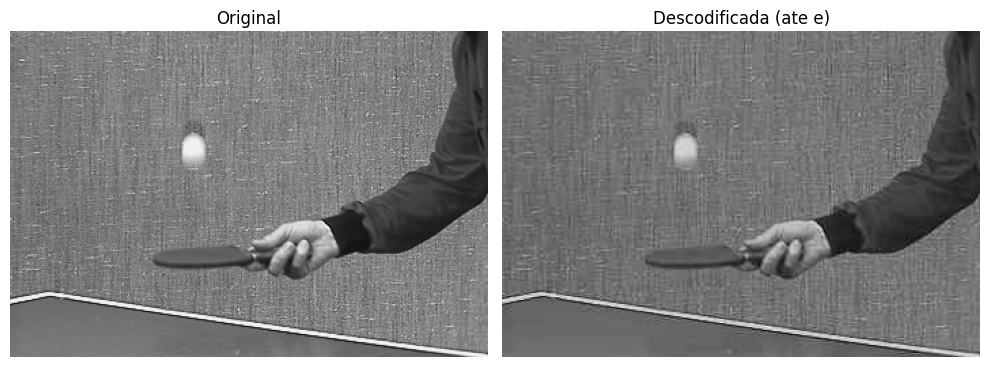

In [6]:
def encode_arrays_from_qcoeff(qcoeff):
    dc_values = []
    ac_pairs_per_block = []
    for _, _, block in block_iter(qcoeff):
        dc_values.append(int(block[0, 0]))
        ac_pairs_per_block.append(ac_rle_encode_from_block(block))
    dc_diff = dc_differential_encode(dc_values)
    return dc_diff, ac_pairs_per_block


def decode_qcoeff_from_arrays(dc_diff, ac_pairs_per_block, shape):
    hp, wp = shape
    qcoeff = np.zeros((hp, wp), dtype=np.int16)
    dc_values = dc_differential_decode(dc_diff)

    block_idx = 0
    for i in range(0, hp, 8):
        for j in range(0, wp, 8):
            block = ac_rle_decode_to_block(dc_values[block_idx], ac_pairs_per_block[block_idx])
            qcoeff[i : i + 8, j : j + 8] = block
            block_idx += 1
    return qcoeff


img = read_gray_image(IMG_PATH)
coeff, h, w = dct2_blocks(img)
qcoeff, qmat = quantize_blocks(coeff, q=50)

dc_diff_arr, ac_pairs_arr = encode_arrays_from_qcoeff(qcoeff)
qcoeff_rec = decode_qcoeff_from_arrays(dc_diff_arr, ac_pairs_arr, qcoeff.shape)

coeff_rec = dequantize_blocks(qcoeff_rec, qmat)
img_rec = idct2_blocks(coeff_rec, h, w)

print("Reconstrucao de arrays (c+d) correta?", np.array_equal(qcoeff, qcoeff_rec))
print(f"SNR final da pipeline (ate e), q=50: {snr_db(img, img_rec):.2f} dB")
show_images_side_by_side(img, img_rec, "Original", "Descodificada (ate e)")

### Alínea f

In [7]:
def magnitude_category(v):
    v = int(v)
    if v == 0:
        return 0
    return int(np.floor(np.log2(abs(v))) + 1)


def value_to_bits(v, size):
    if size == 0:
        return ""
    if v >= 0:
        return format(v, f"0{size}b")
    return format((1 << size) - 1 + v, f"0{size}b")


def bits_to_value(bits, size):
    if size == 0:
        return 0
    x = int(bits, 2)
    if x >= (1 << (size - 1)):
        return x
    return x - ((1 << size) - 1)


def huffman_encode_arrays(dc_diff, ac_pairs_per_block):
    bitstream = []

    for d in dc_diff:
        cat = magnitude_category(d)
        if cat not in K3:
            raise ValueError(f"Categoria DC nao suportada pela tabela K3: {cat}")
        bitstream.append(K3[cat])
        bitstream.append(value_to_bits(d, cat))

    for pairs in ac_pairs_per_block:
        for run, val in pairs:
            if (run, val) == (0, 0):
                bitstream.append(K5[(0, 0)])
                continue
            if (run, val) == (15, 0):
                bitstream.append(K5[(15, 0)])
                continue
            size = magnitude_category(val)
            key = (run, size)
            if key not in K5:
                raise ValueError(f"Par AC nao suportado por K5: {key}")
            bitstream.append(K5[key])
            bitstream.append(value_to_bits(val, size))

    return "".join(bitstream)


def bits_to_bytes(bitstring):
    pad = (8 - (len(bitstring) % 8)) % 8
    bitstring_padded = bitstring + ("0" * pad)
    arr = bytearray()
    for i in range(0, len(bitstring_padded), 8):
        arr.append(int(bitstring_padded[i : i + 8], 2))
    return bytes(arr), pad


def bytes_to_bits(data):
    return "".join(format(b, "08b") for b in data)


def write_bitstream_file(path, bitstring, h, w, hp, wp, q):
    payload, pad = bits_to_bytes(bitstring)
    with open(path, "wb") as f:
        f.write(b"JPGS")
        f.write(struct.pack(">HHHHBI", h, w, hp, wp, int(q), len(bitstring)))
        f.write(payload)
        f.write(struct.pack("B", pad))


def huffman_decode_arrays(bitstring, n_blocks):
    inv_k3 = {v: k for k, v in K3.items()}
    inv_k5 = {v: k for k, v in K5.items()}

    def read_huff_code(s, idx, inv_table):
        cur = ""
        while idx < len(s):
            cur += s[idx]
            idx += 1
            if cur in inv_table:
                return inv_table[cur], idx
        raise ValueError("Fim inesperado do bitstream ao ler Huffman")

    idx = 0
    dc_diff = []
    for _ in range(n_blocks):
        cat, idx = read_huff_code(bitstring, idx, inv_k3)
        amp = bitstring[idx : idx + cat]
        idx += cat
        dc_diff.append(bits_to_value(amp, cat))

    ac_pairs_per_block = []
    for _ in range(n_blocks):
        pairs = []
        while True:
            symbol, idx = read_huff_code(bitstring, idx, inv_k5)
            run, size = symbol
            if (run, size) == (0, 0):
                pairs.append((0, 0))
                break
            if (run, size) == (15, 0):
                pairs.append((15, 0))
                continue
            amp = bitstring[idx : idx + size]
            idx += size
            pairs.append((run, bits_to_value(amp, size)))
        ac_pairs_per_block.append(pairs)

    return dc_diff, ac_pairs_per_block


def read_bitstream_file(path):
    with open(path, "rb") as f:
        magic = f.read(4)
        if magic != b"JPGS":
            raise ValueError("Ficheiro invalido: magic nao reconhecida")

        h, w, hp, wp, q, n_bits = struct.unpack(">HHHHBI", f.read(2 + 2 + 2 + 2 + 1 + 4)
        )
        data = f.read()
        pad = data[-1]
        payload = data[:-1]

    bits = bytes_to_bits(payload)[:n_bits]
    return bits, h, w, hp, wp, q


img = read_gray_image(IMG_PATH)
coeff, h, w = dct2_blocks(img)
q = 50
qcoeff, _ = quantize_blocks(coeff, q=q)
dc_diff_arr, ac_pairs_arr = encode_arrays_from_qcoeff(qcoeff)

bitstring = huffman_encode_arrays(dc_diff_arr, ac_pairs_arr)
out_file = TP4_DIR / "jpeg_seq_bits.bin"
write_bitstream_file(out_file, bitstring, h, w, qcoeff.shape[0], qcoeff.shape[1], q)

print(f"Ficheiro gerado: {out_file.name}")
print(f"Bits codificados: {len(bitstring)}")
print(f"Tamanho em bytes: {out_file.stat().st_size}")

Ficheiro gerado: jpeg_seq_bits.bin
Bits codificados: 47570
Tamanho em bytes: 5965


### Alínea g

Primeiros 10 valores DC diferenciais lidos: [-31, 0, 0, 0, 0, 1, 0, 0, 1, -1]
Primeiros pares AC do 1.o bloco: [(0, -1), (0, 1), (1, 1), (0, 1), (2, -1), (2, -1), (0, -1), (5, -1), (0, 0)]
SNR apos leitura do ficheiro: 21.02 dB
Taxa de compressao aproximada: 14.21x


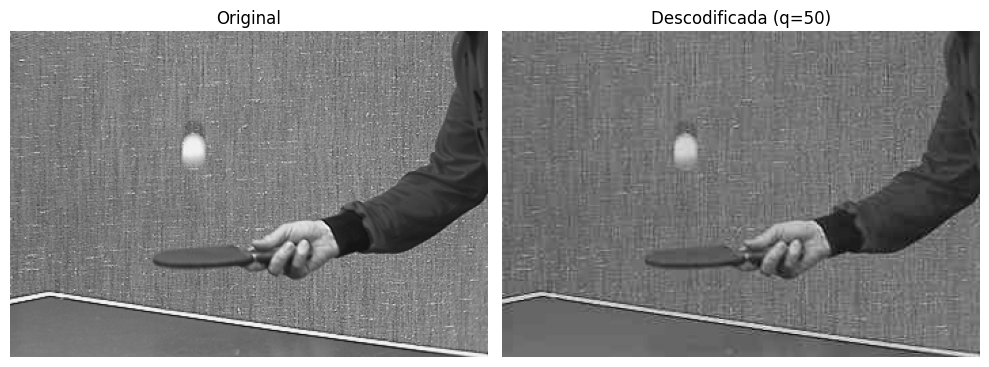

In [8]:
bits_in, h, w, hp, wp, q = read_bitstream_file(TP4_DIR / "jpeg_seq_bits.bin")
n_blocks = (hp // 8) * (wp // 8)

dc_diff_dec, ac_pairs_dec = huffman_decode_arrays(bits_in, n_blocks)

# arrays pedidos na alinea g
print("Primeiros 10 valores DC diferenciais lidos:", dc_diff_dec[:10])
print("Primeiros pares AC do 1.o bloco:", ac_pairs_dec[0][:12])

# reconstrucao completa da imagem a partir do ficheiro
img = read_gray_image(IMG_PATH)
coeff, _, _ = dct2_blocks(img)
_, qmat = quantize_blocks(coeff, q=q)

qcoeff_dec = decode_qcoeff_from_arrays(dc_diff_dec, ac_pairs_dec, (hp, wp))
coeff_dec = dequantize_blocks(qcoeff_dec, qmat)
img_dec = idct2_blocks(coeff_dec, h, w)

snr = snr_db(img, img_dec)
orig_bits = h * w * 8
comp_bits = len(bits_in)
cr = orig_bits / comp_bits if comp_bits > 0 else np.inf

print(f"SNR apos leitura do ficheiro: {snr:.2f} dB")
print(f"Taxa de compressao aproximada: {cr:.2f}x")

show_images_side_by_side(img, img_dec, "Original", f"Descodificada (q={q})")

## Exercício 2
### Alínea a

In [9]:
def taxa(path):
    taxas=[]

    original_frames = [os.path.join(path+'/', f) for f in sorted(os.listdir(path+'/'), key=lambda x: (len(x), x))]
    decoded_frames = [os.path.join(path+'_JPEG_compressed/', f) for f in sorted(os.listdir(path+'_JPEG_compressed/'), key=lambda x: (len(x), x))]

    for original_frame,decoded_frame in zip(original_frames,decoded_frames):
        original_size = os.path.getsize(original_frame)
        decompressed_size= os.path.getsize(decoded_frame)
        taxas.append(original_size/decompressed_size)
    return taxas

A <b>taxa de compressão</b> de imagens é uma medida que indica o grau de redução do tamanho do ficheiro.<br>Ou seja, consiste em uma medida da eficiência da compressão, expressa como a razão entre o tamanho original do ficheiro e o tamanho do ficheiro comprimido.

### Alínea b

In [10]:
def snr(original, reconstruido):
    MSE=np.sum((original-reconstruido)**2)
    return 10*np.log10(np.sum(original**2)/MSE)


<b>Mean-Square Error (MSE)</b> avalia a qualidade de imagens comprimidas. Esta medida representa o erro quadrático entre a imagem comprimida e original. Quanto menor o valor, menor o erro.<br>
$MSE = 1/N \sum_i (org_i - app_i)^2$<br> utilizamos para calcular o SNR.

O <b>Signal-to-Noise Ratio (SNR)</b> avalia a qualidade de uma imagem relativamente ao nível de ruído presente. Um SNR maior indica maior qualidade de imagem.<br>
$ SNR_{dBs} =10 \log(\frac{P_{app}}{MSE}$)


### Alínea c

In [11]:
def entropia(original):
    hist, _ = np.histogram(original.flatten(), bins=256, range=[0,256])
    hist = hist / hist.sum()
    return -np.sum(hist * np.log2(hist+1e-9))


<b>Entropia</b>: mede a quantidade de redundância presente na imagem, ou seja, a quantidade de padrões previsíveis ou repetitivos.<br>
$H(S) = -\sum_{i=1}^{N} p(s_{i})\log_{2}p(s_{i})$<br>
Quanto maior a entropia, mais complexa e menos previsível é a imagem, e mais difícil é comprimi-la sem perder informações importantes.

### Alínea d

In [12]:
def energia(original):
    return np.mean(original**2)


A <b>potência</b> de um imagem, ou <b>energia,</b> refere-se à intensidade média dos valores dos pixels: $E_x = 1/N \sum_i (x_i)^2$

### Alínea e

In [13]:
def calculo(frames_original, frames_reconstruido,path):
    taxas=taxa(path)
    snrs=[]
    entropias=[]
    energias=[]

    for original, reconstruido in zip(frames_original, frames_reconstruido):
        snrs.append(snr(original, reconstruido))
        entropias.append(entropia(reconstruido))
        energias.append(energia(reconstruido))

    print('Taxas: ',taxas)
    print('SNR:', snrs)
    print('Entropias: ', entropias)
    print('Energias: ',energias)
    
    return taxas, snrs, entropias, energias

def graficos(taxas, snrs, entropias, energias, tempos_compressao, tempos_descompressao):
    frames = range(len(snrs))

    plt.figure(figsize=(10, 5))

    plt.subplot(2, 3, 1)
    plt.plot(frames, taxas, label='Taxa de Compressão')
    plt.xlabel('Frame')
    plt.ylabel('Taxa de Compressão')
    plt.legend()

    plt.subplot(2, 3, 2)
    plt.plot(frames, snrs, label='SNR (dB)', color='orange')
    plt.xlabel('Frame')
    plt.ylabel('SNR (dB)')
    plt.legend()

    plt.subplot(2, 3, 3)
    plt.plot(frames, entropias, label='Entropia', color='green')
    plt.xlabel('Frame')
    plt.ylabel('Entropia')
    plt.legend()

    plt.subplot(2, 3, 4)
    plt.plot(frames, energias, label='Energia', color='red')
    plt.xlabel('Frame')
    plt.ylabel('Energia')
    plt.legend()

    plt.subplot(2, 3, 5)
    plt.plot(frames, tempos_compressao, label='Tempo de Compressão', color='purple')
    plt.xlabel('Frame')
    plt.ylabel('Tempo de Compressão (s)')
    plt.legend()

    plt.subplot(2, 3, 6)
    plt.plot(frames, tempos_descompressao, label='Tempo de Descompressão', color='brown')
    plt.xlabel('Frame')
    plt.ylabel('Tempo de Descompressão (s)')
    plt.legend()

    plt.tight_layout()
    plt.show()

## Extra 


### Alínea a

In [14]:
def codificador_intra_frame(path,qualidade):
    original_frames = [cv2.imread(os.path.join(path, f)) for f in sorted(os.listdir(path), key=lambda x: (len(x), x))] 

    path=path+'_JPEG_compressed'
    if not os.path.exists(path):
        os.makedirs(path)

    coded_frames = []
    tempos_compressao=[]

    for i in range(len(original_frames)):
        start=time()
        cv2.imwrite(path+'/'+ str(i+1) + '.jpg', original_frames[i] , (cv2.IMWRITE_JPEG_QUALITY, qualidade))
        filepath = path+"/" + str(i+1) + ".jpg"
        frame_codificado = cv2.imread(filepath)
        coded_frames.append(frame_codificado)
        tempo_compressao=time()-start
        tempos_compressao.append(tempo_compressao)

    return tempos_compressao,original_frames, coded_frames

def descodificador_intra_frame(coded_frames):
    decoded_frames = []
    tempos_descompressao = []

    for i, frame in enumerate(coded_frames):
        start = time()
        decoded_frames.append(frame)
        tempo_descompressao = time() - start
        tempos_descompressao.append(tempo_descompressao)
    
    return tempos_descompressao, decoded_frames

<b> Codificador intraframe</b> consiste na remoção de redundância espacial ao utilizar uma compressão semelhante ao JPEG: DCT, quantificação, VLC.
O codificador lê as frames no caminho especificado, comprime cada frame como um arquivo JPEG com qualidade de 50% e guarda as imagens. Os novos frames são guardadados numa nova pasta e num array que é retornado. Os tempos de compressão por frame também são retornados.
<b> Descodificador intraframe</b> o descodificador recebe a lista de frames codificado e o caminho dos frames originais.
Cada frame codificado é guardado como um arquivo JPEG no diretório de descompressão e adiciona a imagem à lista decoded_frames. Os tempos de descompressão são calculados e armazenados para então serem retornados juntamente com a lista dos frames decodificados.

In [15]:
def intraframe(path,qualidade):

    tempos_compressao, original_frames, coded_frames = codificador_intra_frame(path,qualidade)
    tempos_descompressao,decoded_frames = descodificador_intra_frame(coded_frames)
    # print(original_frames[0])
    print("teste")
    print(coded_frames[0])
    
    plt.figure(figsize=(10, 5))

    for i in range(1, len(coded_frames)+1):
        plt.subplot(4, 4, i)
        plt.imshow(coded_frames[i-1], cmap='gray')
        plt.axis('off')

    plt.figure(figsize=(10, 5))
    for i in range(1, len(decoded_frames)+1):
        plt.subplot(4, 4, i)
        plt.imshow(decoded_frames[i-1], cmap='gray')
        plt.axis('off')

    taxas, snrs, entropias, energias=calculo(original_frames, decoded_frames,path)
    print('Tempo de compressão: ', tempos_compressao)
    print('Tempo de decompressão: ', tempos_descompressao)
    graficos(taxas, snrs, entropias, energias, tempos_compressao, tempos_descompressao)

teste
[[[ 57  57  57]
  [ 61  61  61]
  [ 68  68  68]
  ...
  [ 31  31  31]
  [ 30  30  30]
  [ 30  30  30]]

 [[ 69  69  69]
  [ 68  68  68]
  [ 67  67  67]
  ...
  [ 31  31  31]
  [ 31  31  31]
  [ 30  30  30]]

 [[ 80  80  80]
  [ 75  75  75]
  [ 67  67  67]
  ...
  [ 32  32  32]
  [ 31  31  31]
  [ 31  31  31]]

 ...

 [[ 63  63  63]
  [ 63  63  63]
  [ 63  63  63]
  ...
  [ 67  67  67]
  [ 52  52  52]
  [ 37  37  37]]

 [[ 64  64  64]
  [ 64  64  64]
  [ 64  64  64]
  ...
  [126 126 126]
  [120 120 120]
  [108 108 108]]

 [[ 64  64  64]
  [ 64  64  64]
  [ 64  64  64]
  ...
  [124 124 124]
  [118 118 118]
  [102 102 102]]]
Taxas:  [12.036259814418273, 12.02966343411295, 11.974435449510013, 12.019951546244833, 12.017106200997862, 11.962768225095921, 11.980096673301109, 11.964493679875018, 11.913522679101314, 11.890739695087522, 11.885343123411465]
SNR: [np.float64(5.66302011127616), np.float64(5.653552506428449), np.float64(5.57814483468913), np.float64(5.5395110211290834), np.floa

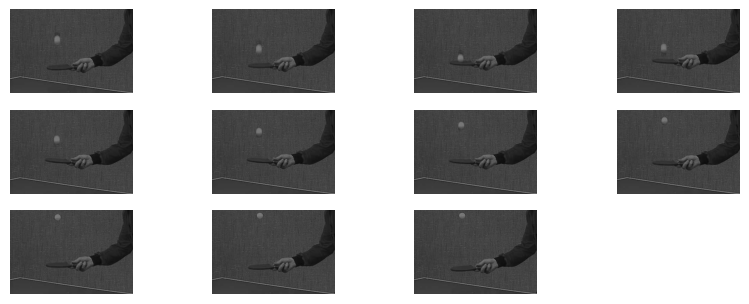

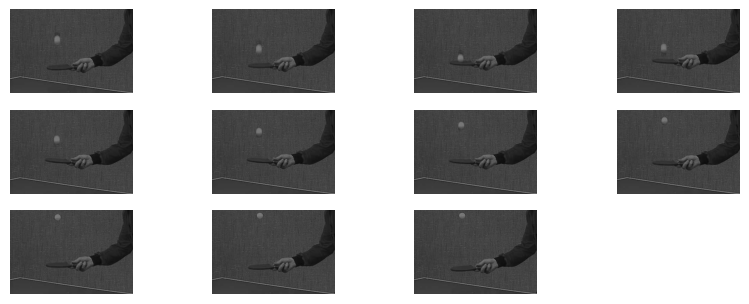

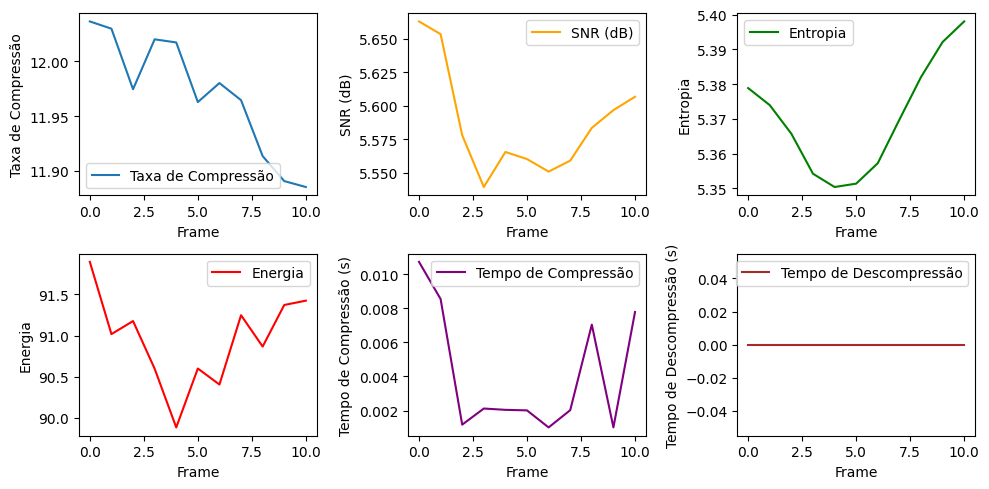

teste
[[[146 146 146]
  [146 146 146]
  [146 146 146]
  ...
  [146 146 146]
  [146 146 146]
  [146 146 146]]

 [[146 146 146]
  [146 146 146]
  [146 146 146]
  ...
  [146 146 146]
  [146 146 146]
  [146 146 146]]

 [[146 146 146]
  [146 146 146]
  [146 146 146]
  ...
  [146 146 146]
  [146 146 146]
  [146 146 146]]

 ...

 [[185 185 185]
  [185 185 185]
  [185 185 185]
  ...
  [182 182 182]
  [182 182 182]
  [183 183 183]]

 [[186 186 186]
  [186 186 186]
  [186 186 186]
  ...
  [183 183 183]
  [182 182 182]
  [182 182 182]]

 [[186 186 186]
  [186 186 186]
  [186 186 186]
  ...
  [189 189 189]
  [188 188 188]
  [187 187 187]]]
Taxas:  [4.924937447873227, 4.916057891109579, 4.922805589472256, 5.040184007576783, 4.903711672942443, 4.947680690399137, 4.89738430583501, 4.922558014031301, 4.927152317880795, 4.996482683982684, 4.992176103964991]
SNR: [np.float64(7.729135846419565), np.float64(7.574353778417181), np.float64(7.684774507092888), np.float64(7.6826757006633715), np.float64(7.589

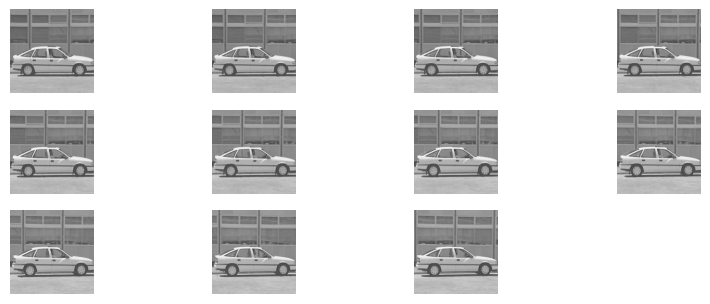

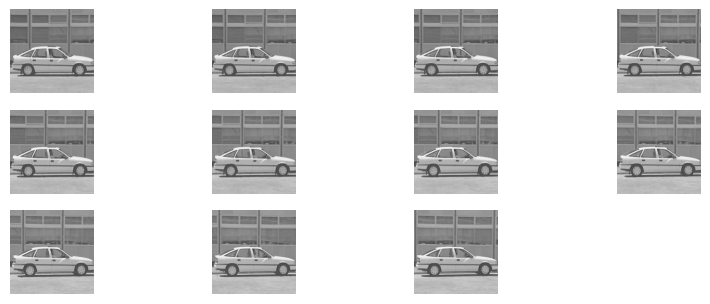

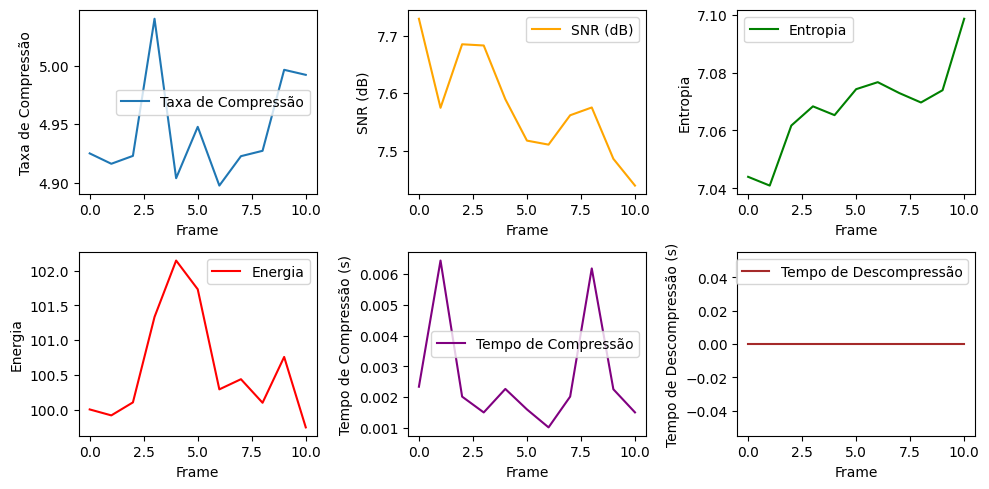

In [16]:
intraframe('bola_seq',50)
intraframe('carro_seq',50)

Podemos concluir que:
* Os tempos de compressão e descompressão são baixos que indica boa eficiencia;
* A energia mantem-se elevada na maioria dos frames;
* Sabendo que para uma imagem em tons de cinza, onde cada pixel pode ter 256 valores de intensidade, uma entropia maxima é de 8. Verificamos então que, neste caso, os valores observados, entre 7.04 e 7.10, são elevados, traduzindo uma alta imprevisibilidade ou complexidade nas imagens;
* A SNR varia entre aproximadamente 7.5 e 7.7, indicando que a potência do sinal é de aproximadamente 7.5 a 7.7 vezes maior do que a potência do ruído presente nas imagens, sugerindo uma boa qualidade de imagem;
* As taxas de compressão manteram-se compreendidas entre 0.004 e 0.0055, significando que o tamanho original do arquivo é aproximadamente 0.004 - 0.006 vezes maior do que o tamanho do arquivo descomprimido.

### Alínea b

In [17]:
def codificador_inter_frame(frames,path,qualidade):
    coded_frames = []
    tempos_compressao=[]
    
    if not os.path.exists(path+'_compressed'):
        os.makedirs(path+'_compressed')
 
    for i, frame in enumerate(frames):
        start=time()
        if i==0:
            i_frame=frames[0]
            coded_frames.append(i_frame)
            cv2.imwrite(path+'_compressed/'+ str(1) + '.jpg', i_frame , (cv2.IMWRITE_JPEG_QUALITY, qualidade))

        else:
            frame_atual = frames[i]
            p_frame = frame_atual*1.0 - i_frame*1.0
            p_frame=(p_frame+255)/2
            p_frame = p_frame.astype(np.uint8)
            coded_frames.append(p_frame)
            cv2.imwrite(path+'_compressed/'+ str(i+1) + '.jpg', p_frame , (cv2.IMWRITE_JPEG_QUALITY, qualidade))
        tempo_compressao=time()-start
        tempos_compressao.append(tempo_compressao)
        
    return tempos_compressao,coded_frames       

def descodificador_inter_frame(frames):
    decoded_frames = []
    tempos_descompressao=[]

    for i, frame in enumerate(frames):
        start=time()
        if i==0:
            i_frame=frames[0]
            decoded_frames.append(i_frame)
        else:
            frame_atual = frames[i]*1.
            frame_atual=(frame_atual*1.*2)-255
            p_frame = frame_atual*1.0 + i_frame*1.0
            p_frame = p_frame.astype(np.uint8)
            decoded_frames.append(p_frame)
        
        tempo_descompressao=time()-start
        tempos_descompressao.append(tempo_descompressao)

    return tempos_descompressao, decoded_frames

## Codificador interframe:
Uma codificação interframe consiste na remoção da redundância temporal. Cada frame é comparados e apenas as diferenças entre elas são armazenadas, resultando em uma redução significativa no tamanho da imagem.

O método gera uma lista de frames codificados onde o primeiro é um i_frame que não sofre alterações e será usado para codificar os restantes, p_frame.
O p_frame é codificado a partir da diferença entre o frame atual e o i_frame.
Para normalizar o frame, a diferença é escalada para o intervalo [0, 255] adicionando 255 e dividindo por 2, para garantir que a P-frame possa ser representada como uma imagem válida (evitando valores negativos). Converte a P-frame para o tipo uint8 (8 bits por canal) e adiciona à lista de frames codificados.

## Descodificador interframe:
O descodificador reconstruirá as frames originais.
Para tal, para cada P-frame (frame_atual), a diferença é revertida escalando de volta ao intervalo original, subtraindo 255 e multiplicando por 2.
A P-frame é então somada à I-frame para reconstruir o frame_atual.
Converte-se o frame reconstruído para o tipo uint8 e adiciona à lista de frames decodificados.

In [18]:
def interframe(path,qualidade):
    original_frames = [cv2.imread(os.path.join(path, f)) for f in sorted(os.listdir(path), key=lambda x: (len(x), x))]    
    print(len(original_frames[0]))
    tempos_compressao, coded_frames = codificador_inter_frame(original_frames,path,qualidade)
    tempos_descompressao, decoded_frames = descodificador_inter_frame(coded_frames)

    plt.figure(figsize=(10, 5))
    for i in range(1, len(original_frames)+1):
        plt.subplot(4, 4, i)
        plt.imshow(original_frames[i-1], cmap='gray')
        plt.axis('off')

    plt.figure(figsize=(10, 5))
    for i in range(1, len(coded_frames)+1):
        plt.subplot(4, 4, i)
        plt.imshow(coded_frames[i-1], cmap='gray')
        plt.axis('off')

    plt.figure(figsize=(10, 5))
    for i in range(1, len(decoded_frames)+1):
        plt.subplot(4, 4, i)
        plt.imshow(decoded_frames[i-1], cmap='gray')
        plt.axis('off')
    
    taxas, snrs, entropias, energias=calculo(original_frames, decoded_frames,path)
    print('Tempo de compressão: ', tempos_compressao)
    print('Tempo de decompressão: ', tempos_descompressao)
    graficos(taxas, snrs, entropias, energias, tempos_compressao, tempos_descompressao)


240


C:\Users\jorge1\AppData\Local\Temp\ipykernel_46404\1612630429.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  return 10*np.log10(np.sum(original**2)/MSE)


Taxas:  [12.036259814418273, 12.02966343411295, 11.974435449510013, 12.019951546244833, 12.017106200997862, 11.962768225095921, 11.980096673301109, 11.964493679875018, 11.913522679101314, 11.890739695087522, 11.885343123411465]
SNR: [np.float64(inf), np.float64(22.983878447486028), np.float64(22.972026268460183), np.float64(22.98079137524001), np.float64(22.91651424966198), np.float64(22.90420777402101), np.float64(22.922042885472397), np.float64(22.966614183094002), np.float64(22.975185815429082), np.float64(22.988844097130738), np.float64(23.010797176787257)]
Entropias:  [np.float64(5.548375467921684), np.float64(5.557525037514584), np.float64(5.554488933317442), np.float64(5.551560926158859), np.float64(5.539555768221833), np.float64(5.534420903414263), np.float64(5.543014651863764), np.float64(5.554284935537519), np.float64(5.566734782833429), np.float64(5.57367973873896), np.float64(5.578166985907274)]
Energias:  [np.float64(100.275390625), np.float64(99.77508285984848), np.float6

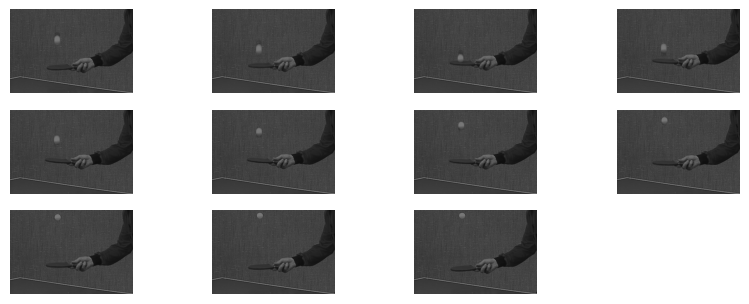

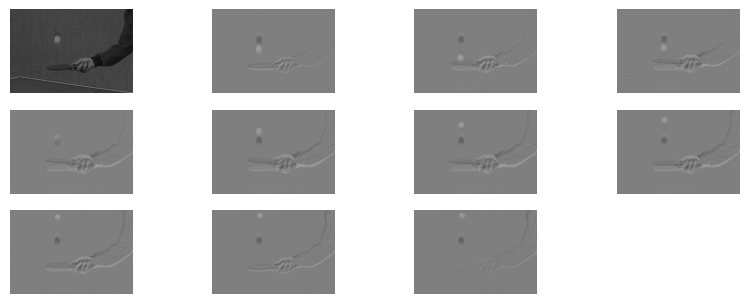

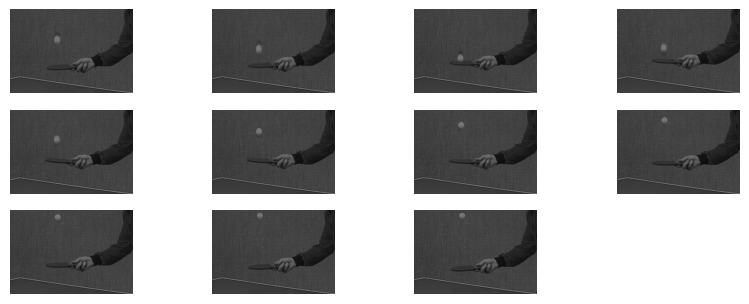

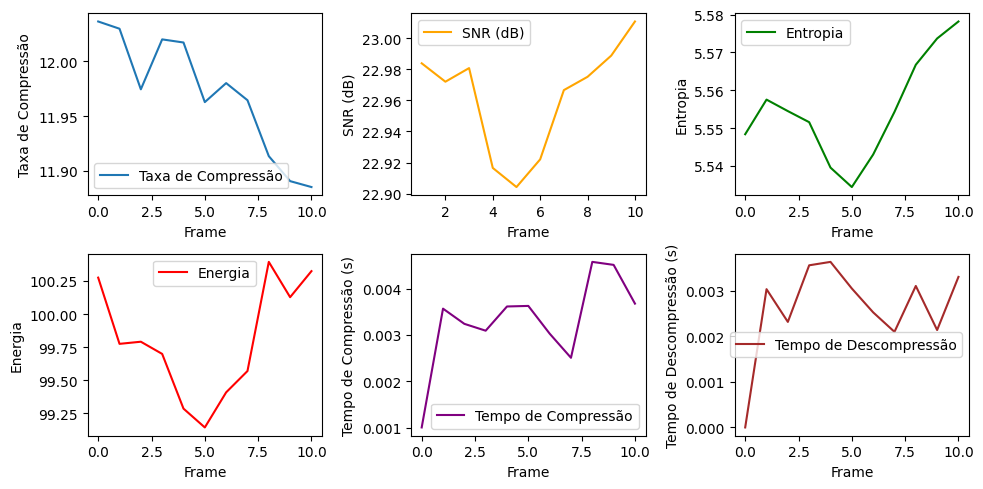

256
Taxas:  [4.924937447873227, 4.916057891109579, 4.922805589472256, 5.040184007576783, 4.903711672942443, 4.947680690399137, 4.89738430583501, 4.922558014031301, 4.927152317880795, 4.996482683982684, 4.992176103964991]
SNR: [np.float64(inf), np.float64(22.60384226197526), np.float64(22.696766636026638), np.float64(22.79756419728646), np.float64(22.814454163350348), np.float64(22.779026067937945), np.float64(22.783965904656686), np.float64(22.765849524790948), np.float64(22.82335220354938), np.float64(22.80992247885287), np.float64(22.727862952414153)]
Entropias:  [np.float64(6.812472060483149), np.float64(6.97052362147747), np.float64(6.984183875784835), np.float64(6.993003567920555), np.float64(7.003520531859621), np.float64(7.013356523060549), np.float64(7.02305140423314), np.float64(7.0226277423703145), np.float64(7.027394975340949), np.float64(7.036004833535955), np.float64(7.052199164381278)]
Energias:  [np.float64(97.2030029296875), np.float64(100.35394287109375), np.float64(10

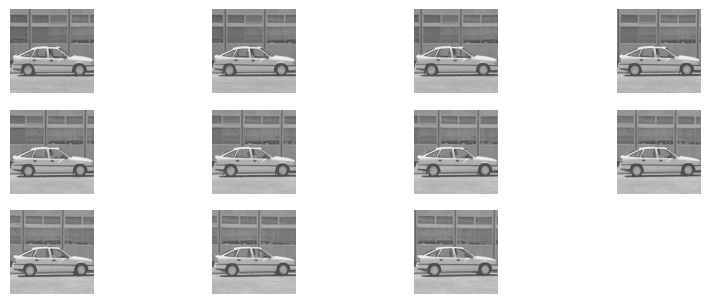

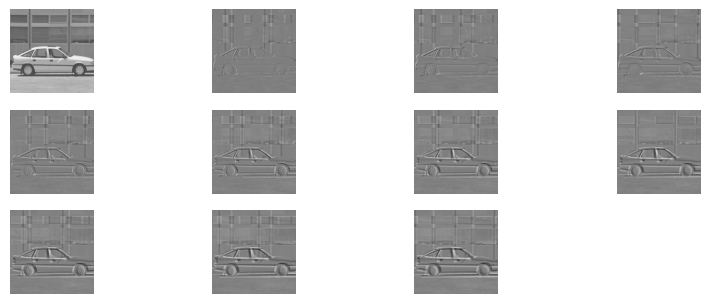

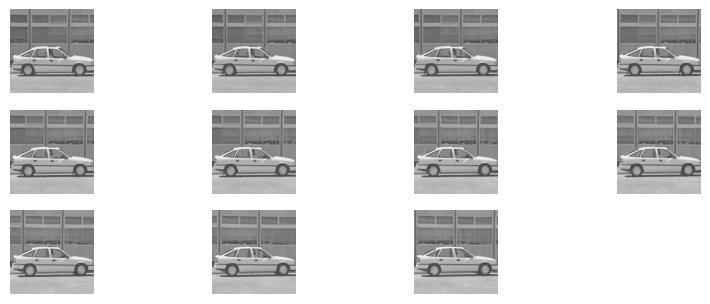

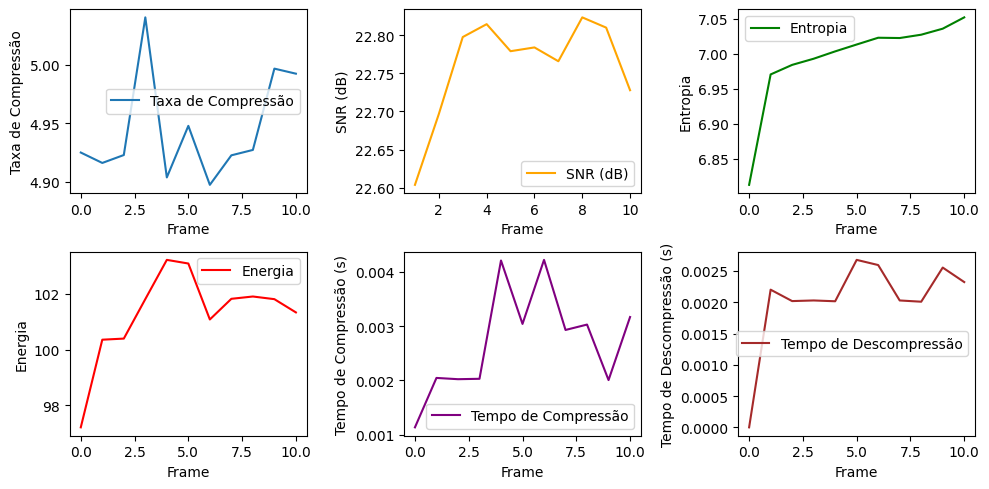

In [19]:
interframe('bola_seq',50)
interframe('carro_seq',50)

Podemos concluir que:
* Os tempos de compressão e descompressão são relativamente baixos;
* A energia da imagem permanece elevada, com valores próximos a 100 na maioria dos frames, sugerindo que as imagens mantêm uma quantidade significativa de informação;
* Novamente, as entropias apresentam-se elevadas, traduzindo uma alta imprevisibilidade ou complexidade nas imagens;
* A SNR mantém-se em torno de 22 dB para os frames subsequentes. Isso sugere que o sinal útil é muito mais forte do que o ruído presente nas imagens;
* As taxas de compressão manteram-se compreendidas entre 4.9 e 5, significando que o tamanho original do arquivo é aproximadamente 4.9 - 5 vezes maior do que o tamanho do arquivo descomprimido.

### Alínea c

#### i. Uma função que realiza a medição do erro absoluto médio entre dois blocos (tamanho 16 16);

In [20]:
def MAE(bloco1, bloco2):
    return np.mean(np.abs(bloco1*1. - bloco2*1.))

#### ii. uma função que realiza uma pesquisa (pode escolher a full-search ou outra) do macro-bloco da frame a codificar numa janela de pesquisa (-15 a +15) da I-frame;

In [21]:
def pesquisa(current_block, i_frame, x_block, y_block):
    
    best_mae = float('inf')
    vector = (0, 0)

    for pixel_x in range(-15*16,16*16+1, 4):
        for pixel_y in range(-15*16,16*16+1, 4):
            ref_pixel_x=x_block+pixel_x
            ref_pixel_y=y_block+pixel_y

            if ref_pixel_x >= 0 and ref_pixel_y >= 0 and ref_pixel_x + 16 <= i_frame.shape[1] and ref_pixel_y + 16 <= i_frame.shape[0]:
                ref_block = i_frame[ref_pixel_y:ref_pixel_y + 16, ref_pixel_x:ref_pixel_x + 16]
                mae = MAE(current_block, ref_block)

                if mae < best_mae:
                    best_mae = mae
                    vector = (pixel_x, pixel_y)

    return vector

A função <b>pesquisa</b> é responsável por implementar um algoritmo de pesquisa que vai procurar corresponder blocos e estimar um vetor de movimento entre um bloco na frame atual e na i_frame.<br>
São inicializadas as variáveis `best_mae`, com um valor alto para armazenar o menor erro médio absoluto encontrado durante a pesquisa de correspondência de blocos, e `vector`, com o vetor de movimento (0, 0), que representa a ausência de movimento.<br>
Para todas as posições possíveis de um bloco 16x16 numa janela de pesquisa 15x15 varia-se as coordenadas pixel_x e pixel_y em ambas as direções.<br>
Caso a posição do bloco de referência estiver dentro dos limites da I frame, calcula-se o MAE entre os blocos do frame atual e da i_frame e atualiza-se a variável `best_mae` de forma a manter o menor valor e variável `vector`.<br>
MAE, <b>Mean Absolute Error</b>, calcula a distância média absoluta entre o pixel de uma imagem e o pixel correspondente noutra imagem. Quanto menor o valor de MAE, menor é a diferença entre as duas imagens.<br>$MAE = 1/N \sum_i |(org_i - app_c)|$

#### iii. uma função que percorra os blocos da frame a codificar e construa a frame predita;

In [22]:
def predicao(frame_atual, i_frame):
    height, width = frame_atual.shape
    predicted_frame = np.zeros_like(frame_atual)
    motion_vectors = []

    for y in range(0, height, 16):
        for x in range(0, width, 16):
            current_block = frame_atual[y:y + 16, x:x + 16]
            mv = pesquisa(current_block, i_frame, x, y)
            motion_vectors.append((x, y, mv[0], mv[1]))

            ref_x = x + mv[0]
            ref_y = y + mv[1]
            predicted_frame[y:y + 16, x:x + 16] = i_frame[ref_y:ref_y + 16, ref_x:ref_x + 16]

    return predicted_frame, motion_vectors

A função <b>predicao</b> implementa a compensação de movimento.
Antes de tudo, inicializa-se uma matriz de zeros com as mesmas dimensões da frame atual para armazenar a frame predita.<br>
Para todos os blocos de dimensão 16x16 na frame atual, realiza-se a pesquisa que retornará um vetor de movimento entre o bloco atual e os blocos correspondentes na frame de referência e adiciona-se à uma lista um tuplo com a posição do bloco e o vetor de movimento correspondente.<br>Com base no vetor de movimento, calcula-se as coordenadas (`ref_x`, `ref_y`) do bloco correspondente na frame de referência.e é copiado para a posição do bloco atual na frame predita (`predicted_frame`).

In [23]:
def resultados(current_frame, predicted_frame, motion_vectors,difference_frame):
    
    plt.figure(figsize=(10, 10))
    plt.subplot(1, 4, 1)
    plt.title('Current Frame')
    plt.imshow(current_frame, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title('Predicted Frame')
    plt.imshow(predicted_frame, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.title('Difference Frame')
    plt.imshow(difference_frame, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.title('Motion Vectors')
    plt.imshow(current_frame, cmap='gray')
    plt.axis('off')
    for (x, y, dx, dy) in motion_vectors:
        pylab.quiver(x + 8, y + 8, dx, dy, color='red', scale=2, scale_units='xy', angles='xy')
    
    plt.show()

In [24]:
def reverter_predicao(i_frame, motion_vectors):
    height, width = i_frame.shape
    predicted_frame = np.zeros_like(i_frame)

    for y in range(0, height, 16):
        for x in range(0, width, 16):
            for vector in motion_vectors:

                if vector[0] == x and vector[1] == y:
                    _,_, a, b = vector
                    if y - a >= 0 and x - b >= 0 and y - a + 16 <= height and x - b + 16 <= width:
                        predicted_frame[y:y + 16, x:x + 16] = i_frame[y - a:y - a + 16, x - b:x - b + 16]

    return predicted_frame

In [25]:
def codificador_Interframe_Compensação_Movimento(path,qualidade):
    frames = [cv2.imread(os.path.join(path, f), cv2.IMREAD_GRAYSCALE) for f in sorted(os.listdir(path), key=lambda x: (len(x), x))]
    tempos_compressao=[]
    frames_motion_vectors = []

    if not os.path.exists(path+'_compensacao_compressed'):
        os.makedirs(path+'_compensacao_compressed')
    
    for i, current_frame in enumerate(frames):
            start=time()
            if i==0:
                i_frame=frames[0]
                cv2.imwrite(path+'_compensacao_compressed/'+ str(1) + '.jpg', i_frame , (cv2.IMWRITE_JPEG_QUALITY, qualidade))

            else:
                predicted_frame, motion_vectors = predicao(current_frame, i_frame)
                difference_frame = current_frame*1. - predicted_frame*1.
                difference_frame=(difference_frame+255)/2
                difference_frame = difference_frame.astype(np.uint8)
                cv2.imwrite(path+'_compensacao_compressed/'+ str(i+1) + '.jpg', difference_frame , (cv2.IMWRITE_JPEG_QUALITY, qualidade))
                frames_motion_vectors.append(motion_vectors)
                resultados(current_frame, predicted_frame, motion_vectors,difference_frame)
            tempo_compressao=time()-start
            tempos_compressao.append(tempo_compressao)

    return tempos_compressao,frames, frames_motion_vectors   

def descodificador_Interframe_Compensação_Movimento(path, frames_motion_vectors):
    frames = [cv2.imread(os.path.join(path, f), cv2.IMREAD_GRAYSCALE) for f in sorted(os.listdir(path), key=lambda x: (len(x), x))] 
    tempos_descompressao=[]
    decoded_frames=[]
    print(len(frames_motion_vectors))
    for i, current_frame in enumerate(frames):
        start=time()
        if i==0:
            i_frame=frames[0]
            decoded_frames.append(i_frame)

        else:
            motion_vectors = frames_motion_vectors[i-1]
            predicted_frame = reverter_predicao(i_frame, motion_vectors)
            image = (current_frame*1.*2)-255        
            image = image*1.0 + predicted_frame*1.0
            image = image.astype(np.uint8)
            decoded_frames.append(image)
            plt.figure(figsize=(10, 10))
            plt.subplot(4, 4, i+1)
            plt.title('Decoded Frame')
            plt.imshow(image, cmap='gray')
            plt.axis('off')
            plt.show()
        tempo_descompressao=time()-start
        tempos_descompressao.append(tempo_descompressao)

    return tempos_descompressao,decoded_frames

In [26]:
def Interframe_Compensação_Movimento(path,qualidade):
    tempos_compressao, original_frames, vetores = codificador_Interframe_Compensação_Movimento(path,qualidade)
    tempos_descompressao, decoded_frames=descodificador_Interframe_Compensação_Movimento(path+'_compensacao_compressed', vetores)
    taxas, snrs, entropias, energias=calculo(original_frames, decoded_frames,path)
    print('Tempo de compressão: ', tempos_compressao)
    print('Tempo de decompressão: ', tempos_descompressao)
    graficos(taxas, snrs, entropias, energias, tempos_compressao, tempos_descompressao)

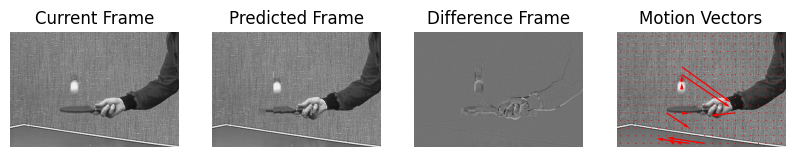

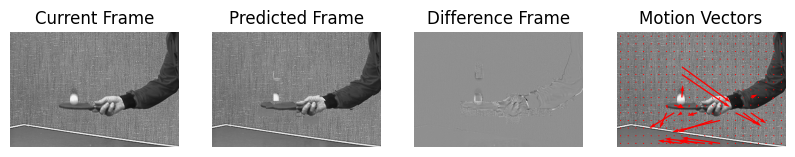

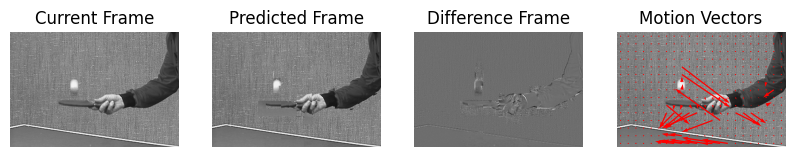

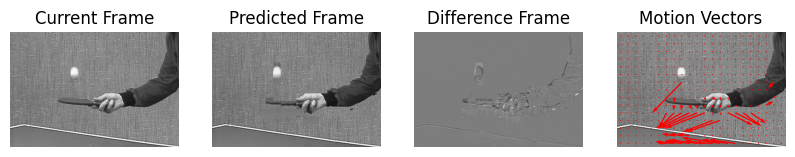

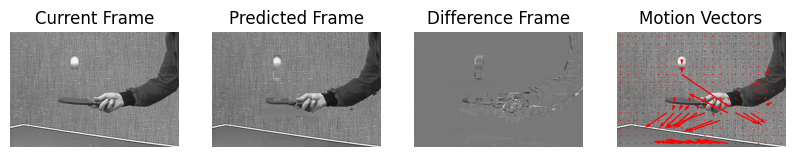

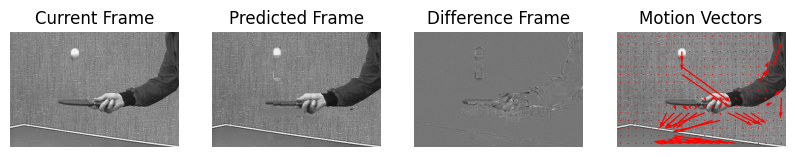

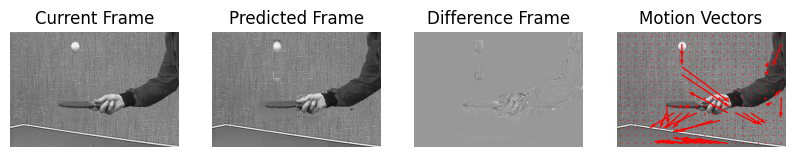

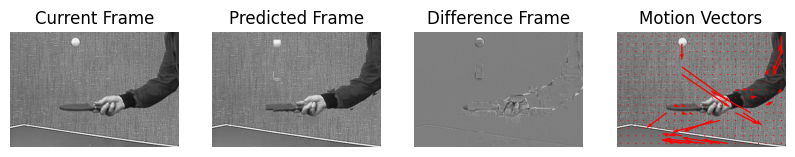

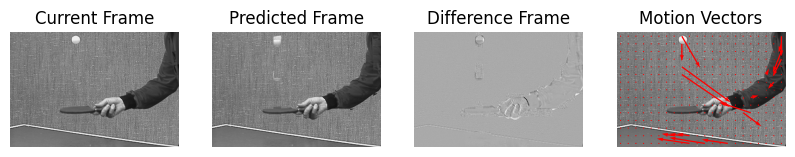

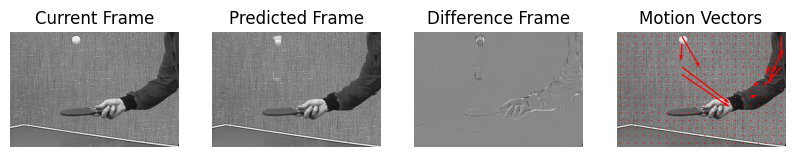

10


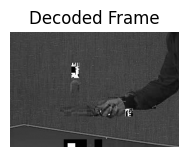

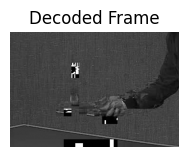

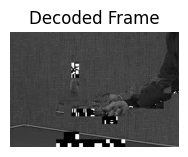

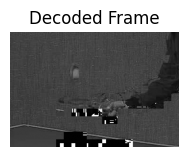

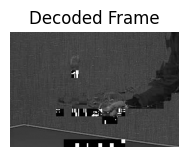

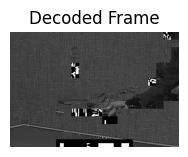

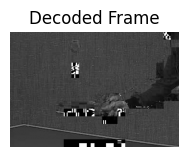

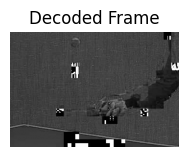

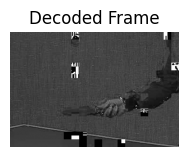

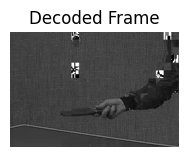

Taxas:  [12.036259814418273, 12.02966343411295, 11.974435449510013, 12.019951546244833, 12.017106200997862, 11.962768225095921, 11.980096673301109, 11.964493679875018, 11.913522679101314, 11.890739695087522, 11.885343123411465]
SNR: [np.float64(5.66302011127616), np.float64(4.517698851218356), np.float64(4.123535337476466), np.float64(3.7051305920783753), np.float64(3.7006471100336817), np.float64(3.700946282323127), np.float64(3.465745947143106), np.float64(3.574701432367225), np.float64(3.5035269629756938), np.float64(3.760400259235433), np.float64(4.45790495218284)]
Entropias:  [np.float64(5.378861768847343), np.float64(5.476353375923933), np.float64(5.4893107885629595), np.float64(5.503907555242955), np.float64(5.465763673980746), np.float64(5.485897191964137), np.float64(5.470744432793121), np.float64(5.5173305326523225), np.float64(5.424455606640082), np.float64(5.446472488401597), np.float64(5.448328139427755)]
Energias:  [np.float64(91.89383285984849), np.float64(98.87671638257

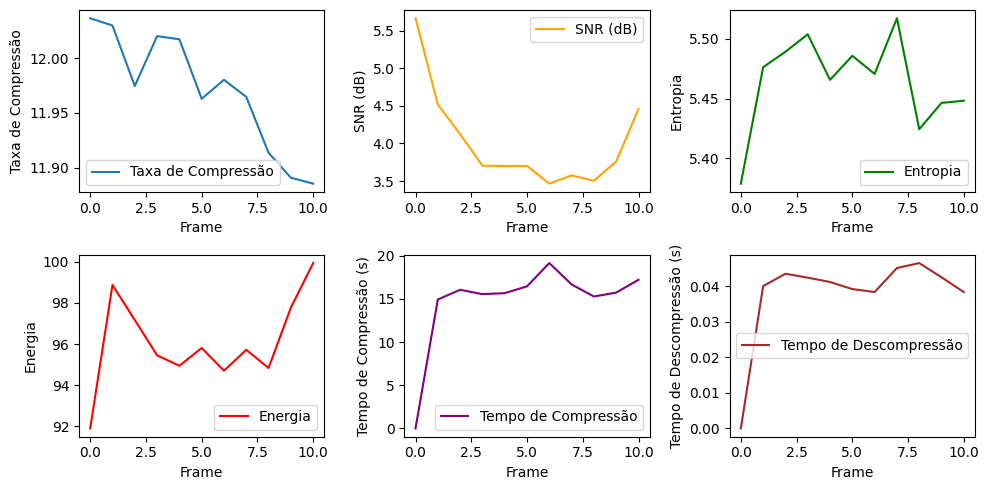

In [27]:
Interframe_Compensação_Movimento('bola_seq',50)

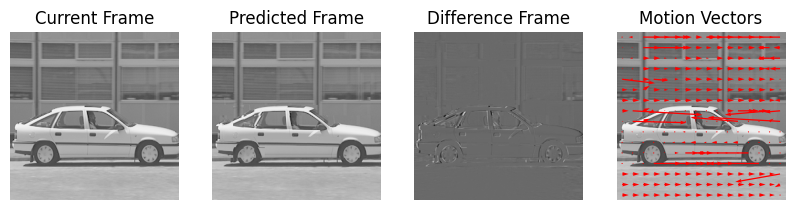

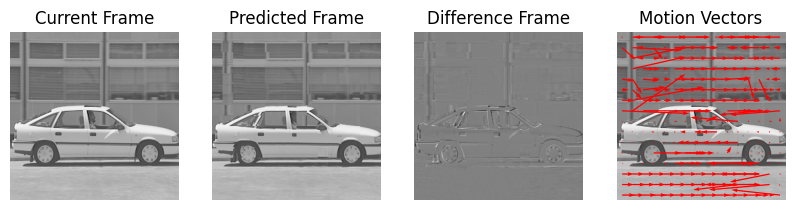

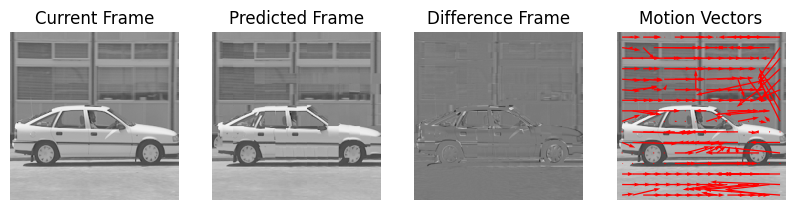

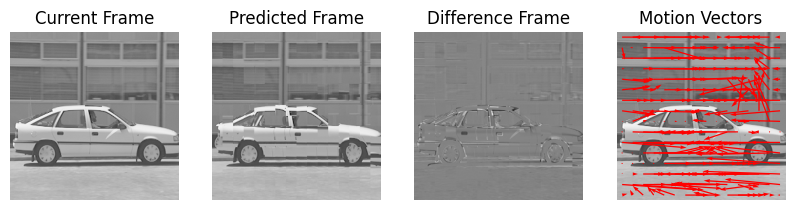

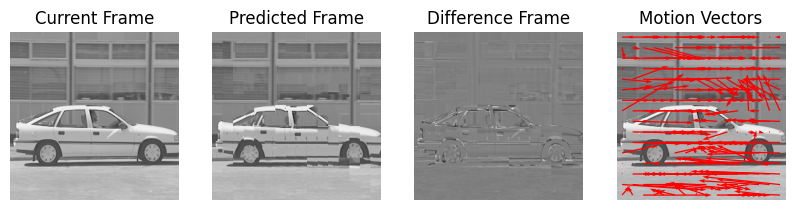

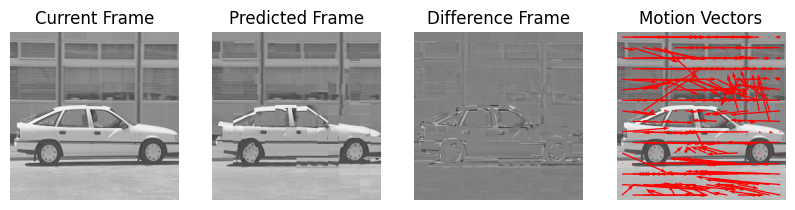

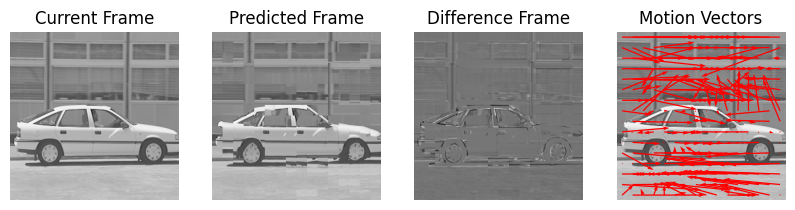

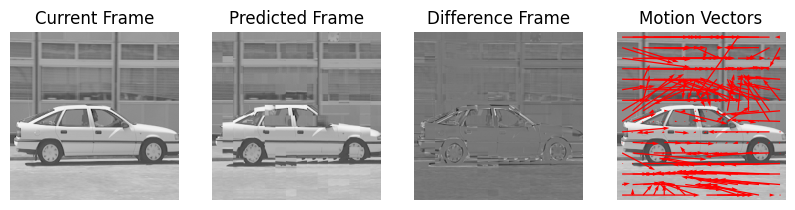

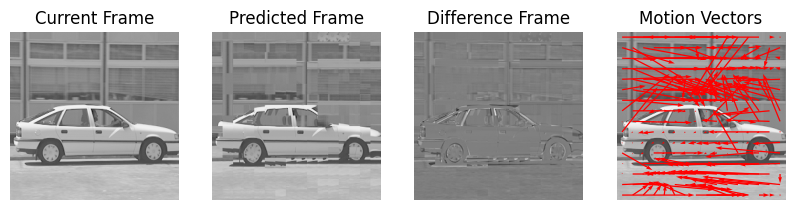

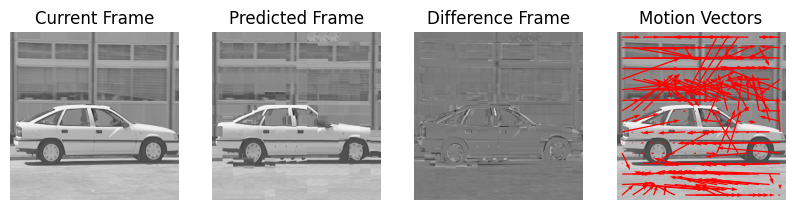

10


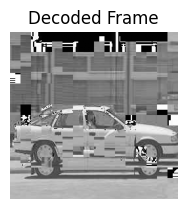

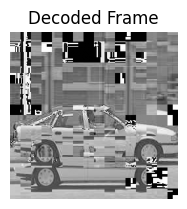

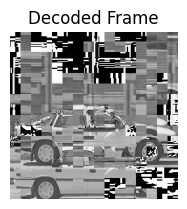

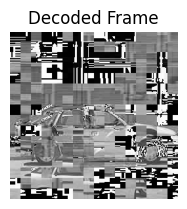

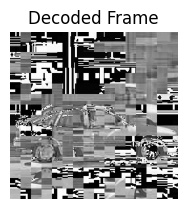

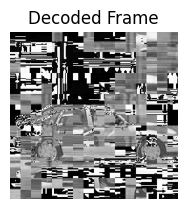

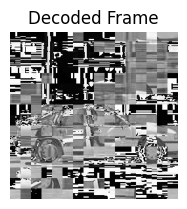

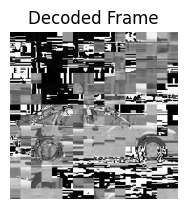

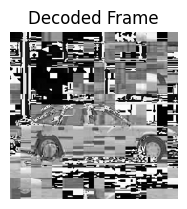

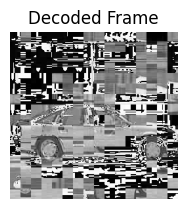

Taxas:  [4.924937447873227, 4.916057891109579, 4.922805589472256, 5.040184007576783, 4.903711672942443, 4.947680690399137, 4.89738430583501, 4.922558014031301, 4.927152317880795, 4.996482683982684, 4.992176103964991]
SNR: [np.float64(7.729135846419565), np.float64(0.7051132948251702), np.float64(0.38464159403838466), np.float64(0.21455131925663842), np.float64(0.06949964538435405), np.float64(-0.07713119606759021), np.float64(-0.08999858322798332), np.float64(0.056472056822137365), np.float64(0.05905291487723932), np.float64(0.13004530188205196), np.float64(0.01182991287423199)]
Entropias:  [np.float64(7.043964545213229), np.float64(7.149373343245254), np.float64(7.244350443353092), np.float64(7.086405572636345), np.float64(6.860431489078436), np.float64(6.729257965415666), np.float64(6.719414038535156), np.float64(6.766870884629451), np.float64(6.7877205765302255), np.float64(6.859255121195737), np.float64(6.794896020938801)]
Energias:  [np.float64(100.001220703125), np.float64(94.726

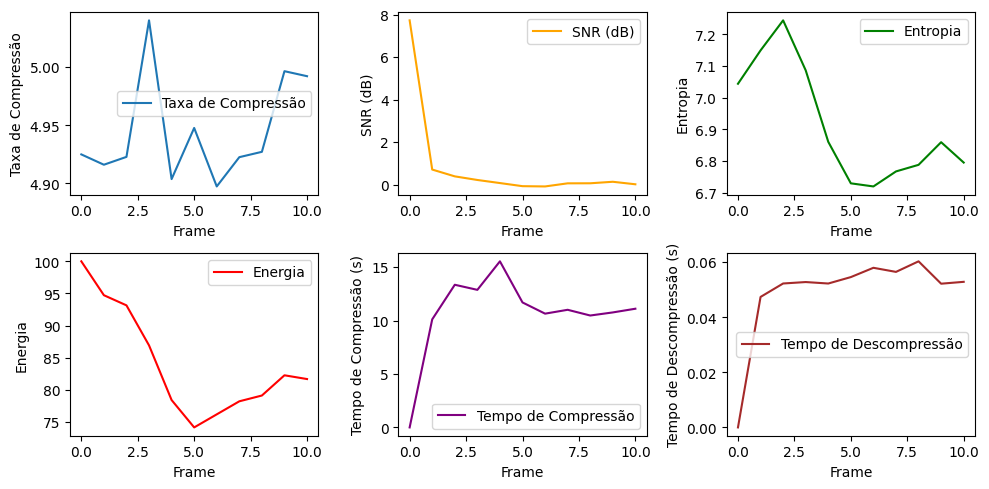

In [28]:
Interframe_Compensação_Movimento('carro_seq',50)